Human in a loop

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

llm = init_chat_model(
    "qwen/qwen3.6-27b",
    model_provider="groq",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, client=<groq.resources.chat.completions.Completions object at 0x0000024EB95846E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024EB9585160>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [2]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human operator for the given query."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tavily_search = TavilySearch(max_results=3)
tools = [tavily_search, human_assistance]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [3]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

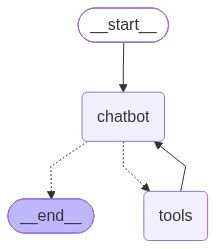

In [4]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass

In [6]:
user_input = "i need expert guidance and assistance on how to implement a chatbot using LangGraph.Could you request assistance from a human operator for the given query and provide me with the necessary guidance and support to successfully implement the chatbot?"

config = {"configurable":{"thread_id":"12345"}}


events = graph.stream(
    {
    "messages": user_input}, 
    config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

i need expert guidance and assistance on how to implement a chatbot using LangGraph.Could you request assistance from a human operator for the given query and provide me with the necessary guidance and support to successfully implement the chatbot?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (v4k2e5jzg)
 Call ID: v4k2e5jzg
  Args:
    query: Expert guidance and assistance on how to implement a chatbot using LangGraph.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (v4k2e5jzg)
 Call ID: v4k2e5jzg
  Args:
    query: Expert guidance and assistance on how to implement a chatbot using LangGraph.


In [7]:
human_responce=("I can help you with that. Please provide more details about your chatbot implementation needs.")

human_command = Command(resume={"data":human_responce})

events = graph.stream(human_command, config=config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (v4k2e5jzg)
 Call ID: v4k2e5jzg
  Args:
    query: Expert guidance and assistance on how to implement a chatbot using LangGraph.
================================= Tool Message =================================
Name: human_assistance

I can help you with that. Please provide more details about your chatbot implementation needs.
================================== Ai Message ==================================

Here is an expert guide to implementing a robust, stateful chatbot using LangGraph. LangGraph is the industry standard for building agentic workflows because it models the system as a **state machine**, allowing for cycles (memory) and conditional logic (decision-making).

### 1. The Core Concepts
Before coding, you must understand the three pillars of LangGraph:
*   **State**: A shared data structure (usually a dictionary) that persists across all nodes.
*   **Nodes**: Fu